# Pizza Sales — Analytics Workbench
**Built on the cleaned data warehouse `03_Data_Warehouse/pizza_dw.duckdb`.**

This notebook analyses the Pizza Place Sales data (FY2015) using the **cleaned dimensional model**
from the `01_Raw_Data → 02_ETL → 03_Data_Warehouse` pipeline. It walks through:

1. Connecting to the warehouse and reviewing the star schema
2. Exploratory data analysis (EDA)
3. Feature engineering for three prediction targets
4. Training & comparing models (Linear Regression, Random Forest, Gradient Boosting)
5. External signals — holidays & (raw) weather
6. Ingredient stocking from a demand forecast
7. **Extension points** — clearly marked places to add your own cleaning & models

> Requirements: `pip install duckdb pandas scikit-learn matplotlib`


## 1 · Connect to the cleaned warehouse

In [1]:
import os, json, duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Resolve the warehouse path whether the notebook runs from the project root or elsewhere
CAND = ["../03_Data_Warehouse/pizza_dw.duckdb", "03_Data_Warehouse/pizza_dw.duckdb",
        "pizza_dw.duckdb",
        os.path.expanduser("~/project_pizza/03_Data_Warehouse/pizza_dw.duckdb")]
DB = next((p for p in CAND if os.path.exists(p)), CAND[0])
con = duckdb.connect(DB, read_only=True)
print("connected:", DB)

# Every table in the cleaned star schema, with row counts
tabs = con.execute('''SELECT table_name FROM duckdb_tables()
                      WHERE schema_name='main' ORDER BY table_name''').df()
tabs["rows"] = [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tabs.table_name]
tabs

connected: ../03_Data_Warehouse/pizza_dw.duckdb


,table_name,rows
0,bridge_pizza_ingredient,181
1,dim_date,365
2,dim_ingredient,65
3,dim_pizza,96
4,dim_time,24
5,dim_weather,23
6,fact_sales_line,48620


### The star schema
`fact_sales_line` sits at the sales-line grain (one row per pizza sold on an order),
surrounded by conformed dimensions:

- **dim_date** (365) — full calendar with `season`, `is_weekend`, `is_holiday`, `is_trading_day`
- **dim_time** (24) — hour of day with `daypart` (Morning / Lunch / Afternoon / Dinner / Late Night) and `is_open`
- **dim_weather** (23) — *banded* weather: `condition_group`, `temp_band`, `precip_level`
- **dim_pizza** (96) — menu: `size_rank`, `unit_price`, `category`, `ingredients`
- **dim_ingredient** (65) + **bridge_pizza_ingredient** (181) — many-to-many for stocking

> Note: the warehouse uses **ISO weekday** (1=Mon … 7=Sun). Convert with `dow % 7` if you want Sunday-first.


In [2]:
# Peek at the fact joined to its dimensions
con.execute('''
  SELECT f.sales_key, d.full_date::DATE AS date, d.day_name, t.hour_24, t.daypart,
         p.pizza_name, p.size_code, w.condition_group, w.temp_band,
         f.quantity, f.line_revenue
  FROM fact_sales_line f
  JOIN dim_date d USING(date_key) JOIN dim_time t USING(time_key)
  JOIN dim_pizza p USING(pizza_key) JOIN dim_weather w USING(weather_key)
  ORDER BY f.sales_key LIMIT 5''').df()

,sales_key,date,day_name,hour_24,daypart,pizza_name,size_code,condition_group,temp_band,quantity,line_revenue
0,1,2015-01-01,Thursday,11,Lunch,The Hawaiian Pizza,M,Clear,1. Freezing (<32F),1,13.25
1,2,2015-01-01,Thursday,11,Lunch,The Classic Deluxe Pizza,M,Clear,1. Freezing (<32F),1,16.00
2,3,2015-01-01,Thursday,11,Lunch,The Five Cheese Pizza,L,Clear,1. Freezing (<32F),1,18.50
3,4,2015-01-01,Thursday,11,Lunch,The Italian Supreme Pizza,L,Clear,1. Freezing (<32F),1,20.75
4,5,2015-01-01,Thursday,11,Lunch,The Mexicana Pizza,M,Clear,1. Freezing (<32F),1,16.00


## 2 · Exploratory data analysis

In [3]:
# Daily sales rolled up from the fact
daily = con.execute('''
  SELECT d.date_key, strftime(d.full_date,'%Y-%m-%d') AS date, (d.day_of_week % 7) AS dow, d.day_name,
         d.month, d.month_name, d.is_weekend, d.is_holiday, d.season,
         COUNT(DISTINCT f.order_id) AS orders, SUM(f.quantity) AS pizzas_sold,
         ROUND(SUM(f.line_revenue),2) AS revenue
  FROM fact_sales_line f JOIN dim_date d USING(date_key)
  GROUP BY ALL ORDER BY d.date_key''').df()
print("Days:", len(daily), "| Revenue:", f"${daily.revenue.sum():,.0f}",
      "| Pizzas:", f"{daily.pizzas_sold.sum():,}")
daily[['pizzas_sold','revenue','orders']].describe().round(1)

Days: 358 | Revenue: $817,860 | Pizzas: 49,574.0


,pizzas_sold,revenue,orders
count,358.0,358.0,358.0
mean,138.5,2284.5,59.6
std,24.4,405.9,10.1
min,77.0,1259.2,27.0
25%,124.0,2047.9,55.0
50%,136.0,2246.0,59.0
75%,150.0,2463.9,64.0
max,266.0,4422.4,115.0


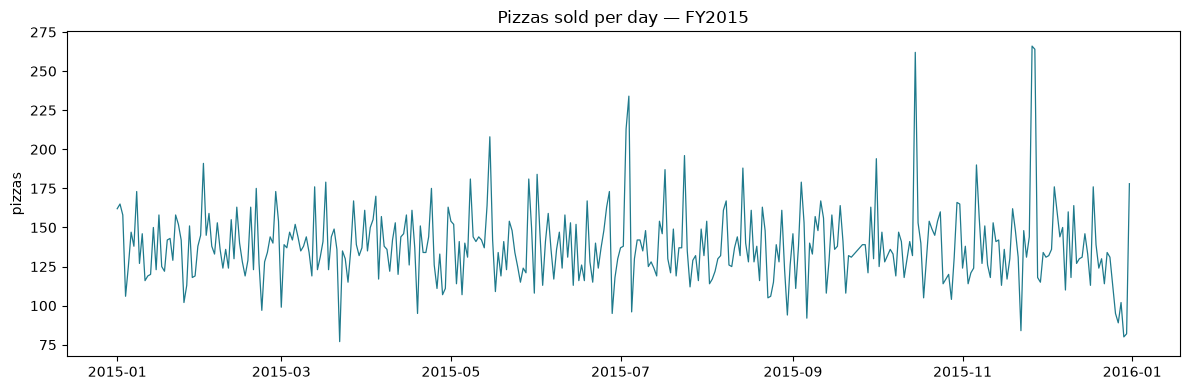

In [4]:
# Sales trend over the year
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(pd.to_datetime(daily.date), daily.pizzas_sold, lw=.9, color='#1f7a8c')
ax.set_title("Pizzas sold per day — FY2015"); ax.set_ylabel("pizzas"); plt.tight_layout()

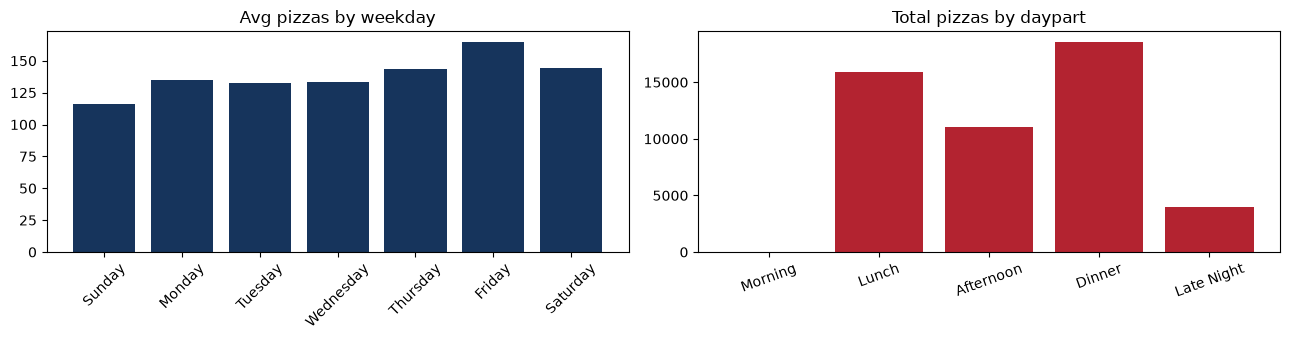

In [5]:
# Demand by weekday and by daypart (the warehouse's own time periods)
wk = con.execute('''SELECT (d.day_of_week % 7) dow, ANY_VALUE(d.day_name) day_name,
      AVG(day_tot) avg_pizzas FROM (
        SELECT date_key, SUM(quantity) day_tot FROM fact_sales_line GROUP BY date_key
      ) s JOIN dim_date d USING(date_key) GROUP BY dow ORDER BY dow''').df()
dp = con.execute('''SELECT t.daypart, SUM(f.quantity) pizzas, MIN(t.hour_24) mn
      FROM fact_sales_line f JOIN dim_time t USING(time_key)
      GROUP BY t.daypart ORDER BY mn''').df()
fig, ax = plt.subplots(1,2, figsize=(13,3.5))
ax[0].bar(wk.day_name, wk.avg_pizzas, color='#16345c'); ax[0].set_title("Avg pizzas by weekday")
ax[0].tick_params(axis='x', rotation=45)
ax[1].bar(dp.daypart, dp.pizzas, color='#b32330'); ax[1].set_title("Total pizzas by daypart")
ax[1].tick_params(axis='x', rotation=20); plt.tight_layout()

In [6]:
# Category & top pizzas
cat = con.execute('''SELECT p.category, ROUND(SUM(f.line_revenue),0) revenue, SUM(f.quantity) pizzas
   FROM fact_sales_line f JOIN dim_pizza p USING(pizza_key) GROUP BY p.category ORDER BY revenue DESC''').df()
print(cat)
con.execute('''SELECT p.pizza_name, p.size_code, ROUND(SUM(f.line_revenue),0) revenue
   FROM fact_sales_line f JOIN dim_pizza p USING(pizza_key)
   GROUP BY p.pizza_name, p.size_code ORDER BY revenue DESC LIMIT 10''').df()

  category   revenue   pizzas
0  Classic  220053.0  14888.0
1  Supreme  208197.0  11987.0
2  Chicken  195920.0  11050.0
3   Veggie  193690.0  11649.0


,pizza_name,size_code,revenue
0,The Thai Chicken Pizza,L,29258.0
1,The Five Cheese Pizza,L,26067.0
2,The Four Cheese Pizza,L,23622.0
3,The Spicy Italian Pizza,L,23012.0
4,The Big Meat Pizza,S,22968.0
5,The Southwest Chicken Pizza,L,21082.0
6,The Barbecue Chicken Pizza,L,20584.0
7,The California Chicken Pizza,L,19235.0
8,The Classic Deluxe Pizza,M,18896.0
9,The Mexicana Pizza,L,17557.0


## 3 · Feature engineering — three prediction targets

We model three business questions:

| Target | Grain | Predict |
|---|---|---|
| **Daily demand** | one day | `pizzas_sold` from calendar features |
| **Hourly demand** | date × hour | `pizzas_sold` from hour + weekday |
| **Pizza revenue** | one pizza (type×size) | `revenue` from menu attributes |


In [7]:
# --- Daily demand features (calendar only, no same-day leakage) ---
daily_feat = daily[['dow','month','is_weekend','is_holiday','pizzas_sold']].copy()
daily_feat['is_weekend'] = daily_feat['is_weekend'].astype(int)
Xd = pd.get_dummies(daily_feat.drop(columns='pizzas_sold'),
                    columns=['dow','month']).astype(float)
yd = daily_feat.pizzas_sold.astype(float)
Xd.head()

,is_weekend,is_holiday,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,month_1,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4 · Train & compare models

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

MODELS = {"Linear Regression": LinearRegression(),
          "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
          "Gradient Boosting": GradientBoostingRegressor(random_state=42)}
CV = KFold(5, shuffle=True, random_state=42)

def benchmark(X, y):
    rows=[]
    for name, m in MODELS.items():
        p = cross_val_predict(m, X, y, cv=CV)
        rows.append({"model":name, "R2":round(r2_score(y,p),3),
                     "MAE":round(mean_absolute_error(y,p),2),
                     "RMSE":round(np.sqrt(mean_squared_error(y,p)),2)})
    return pd.DataFrame(rows)

benchmark(Xd, yd)   # daily demand

,model,R2,MAE,RMSE
0,Linear Regression,0.251,14.81,21.11
1,Random Forest,0.015,17.04,24.21
2,Gradient Boosting,0.063,16.01,23.61


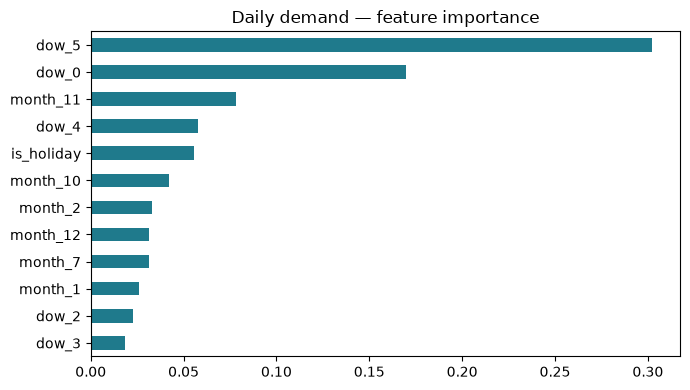

In [9]:
# Feature importance from the Random Forest (daily demand)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xd, yd)
imp = pd.Series(rf.feature_importances_, index=Xd.columns).sort_values(ascending=False)
imp.head(12).plot.barh(figsize=(7,4), color='#1f7a8c'); plt.gca().invert_yaxis()
plt.title("Daily demand — feature importance"); plt.tight_layout()

## 5 · External signals — holidays & weather
`dim_date` already carries `is_holiday`. Weather in the warehouse is stored as **bands**
(`dim_weather`), so for a continuous-weather comparison we re-attach the raw Open-Meteo
daily values from `01_Raw_Data`. Location is *assumed* Chicago — the sales data has no store
location, so treat weather findings with that caveat.

In [10]:
# Attach raw continuous weather to each date
WCAND = ["../01_Raw_Data/weather/openmeteo_archive_chicago_2015.json",
         "01_Raw_Data/weather/openmeteo_archive_chicago_2015.json",
         os.path.expanduser("~/project_pizza/01_Raw_Data/weather/openmeteo_archive_chicago_2015.json")]
WP = next((p for p in WCAND if os.path.exists(p)), WCAND[0])
wj = json.load(open(WP))
wd = pd.DataFrame({"date": pd.to_datetime(wj["daily"]["time"]).strftime("%Y-%m-%d"),
                   "temp_mean": wj["daily"]["temperature_2m_mean"],
                   "precip_mm": wj["daily"]["precipitation_sum"],
                   "snow_cm":   wj["daily"]["snowfall_sum"],
                   "wind_max":  wj["daily"]["wind_speed_10m_max"]})
dw = daily.merge(wd, on="date", how="left")
print("Holiday uplift: {:.0%}".format(
    dw[dw.is_holiday].pizzas_sold.mean()/dw[~dw.is_holiday].pizzas_sold.mean()-1))
print("corr(temp, pizzas):", round(dw.temp_mean.corr(dw.pizzas_sold),3))
print("corr(rain, pizzas):", round(dw.precip_mm.corr(dw.pizzas_sold),3))

Holiday uplift: 16%
corr(temp, pizzas): -0.002
corr(rain, pizzas): 0.02


In [11]:
# Honest feature-set comparison: calendar vs +holiday vs +weather (5-fold CV R2)
dw['is_weekend']=dw['is_weekend'].astype(int); dw['is_holiday']=dw['is_holiday'].astype(int)
def cvr2(feats):
    X = pd.get_dummies(dw[feats], columns=[c for c in ('dow','month') if c in feats]).astype(float)
    return round(r2_score(dw.pizzas_sold, cross_val_predict(LinearRegression(), X, dw.pizzas_sold, cv=CV)),3)
print("calendar only :", cvr2(['dow','month','is_weekend']))
print("+ holiday     :", cvr2(['dow','month','is_weekend','is_holiday']))
print("+ weather     :", cvr2(['dow','month','is_weekend','is_holiday','temp_mean','precip_mm','snow_cm','wind_max']))
# -> holidays add a little; weather adds noise here (assumed location).

calendar only : 0.248
+ holiday     : 0.251
+ weather     : 0.193


## 6 · Ingredient stocking from a demand forecast
`bridge_pizza_ingredient` links each pizza type to its ingredients. Weighting each sold pizza
by size (S=1.0 … XXL=3.0) gives size-weighted portions; dividing by pizzas sold gives a
**per-pizza intensity**, which multiplied by any forecast yields a stocking list.

In [12]:
per_pizza = con.execute('''
    WITH usage AS (
      SELECT ig.ingredient_name AS ingredient,
             SUM(f.quantity * (0.5 + 0.5*p.size_rank)) AS portions_year
      FROM fact_sales_line f JOIN dim_pizza p USING(pizza_key)
      JOIN bridge_pizza_ingredient b ON b.pizza_type_id = p.pizza_type_id
      JOIN dim_ingredient ig ON ig.ingredient_key = b.ingredient_key
      GROUP BY ig.ingredient_name)
    SELECT ingredient,
           ROUND(portions_year * 1.0 / (SELECT SUM(quantity) FROM fact_sales_line), 4) AS per_pizza
    FROM usage ORDER BY per_pizza DESC''').df()

def stocking_list(forecast_pizzas):
    s = per_pizza.copy()
    s["portions_needed"] = (s.per_pizza * forecast_pizzas).round().astype(int)
    return s[["ingredient","portions_needed"]]

# e.g. plan for a forecast of 177 pizzas (a busy holiday Friday)
stocking_list(177).head(10)

,ingredient,portions_needed
0,Garlic,161
1,Tomatoes,154
2,Red Onions,113
3,Red Peppers,94
4,Mozzarella Cheese,61
5,Spinach,54
6,Pepperoni,53
7,Mushrooms,51
8,Chicken,50
9,Capocollo,40


## 7 · Extension points — your turn

The cleaned warehouse is built so you can extend cleanly. Suggested next steps:

- **Use the banded weather**: `dim_weather` groups conditions/temperature/precip — try it as a
  categorical feature instead of the raw continuous values.
- **Richer features**: lag features (yesterday's demand), rolling averages, cyclical encodings
  (sin/cos of hour & month), or daypart interactions.
- **Better hourly model**: hourly demand is non-linear (lunch & dinner peaks) — gradient boosting
  with one-hot hours is usually strongest.
- **New views**: publish your own aggregate tables back into the warehouse for the dashboard.

Write your experiments below.


In [13]:
# TODO (friend): your cleaning / feature ideas here
# Example scaffold — add a 7-day rolling average as a feature:
daily2 = daily[['date','pizzas_sold']].copy()
daily2['roll7'] = daily2.pizzas_sold.rolling(7, min_periods=1).mean()
daily2.tail()

,date,pizzas_sold,roll7
353,2015-12-27,89.0,116.714286
354,2015-12-28,102.0,113.571429
355,2015-12-29,80.0,106.428571
356,2015-12-30,82.0,101.857143
357,2015-12-31,178.0,108.142857


In [14]:
con.close()  # tidy up